# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval Quality Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [ ]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [ ]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [ ]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [ ]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [ ]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [ ]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [ ]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:

When retrieval is a tool, the agent decides whether to use it instead of running it on every question. Before, retrieval ran first every single time, even when the question did not need the corpus, which added latency and cost. Now there is a real decision point: the agent can skip retrieval for out-of-scope or trivial questions, write its own search query, and retrieve more than once if needed. The tradeoff is that answer quality now depends on the agent making that decision well, so you have to inspect whether it actually retrieved instead of trusting the final answer.

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [ ]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")


agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:

Middleware hooks into the existing agent loop at fixed points, so you can add behavior without rebuilding the graph. It does two kinds of things: observe and change. Here the before_model hook observes, logging each step so we can see how the agent is making its decisions, which is useful for debugging. But middleware can also constrain the loop, which is what ModelCallLimitMiddleware does. A model-call limit is useful because the agent chooses its own path, so without a ceiling it could keep calling the model and tools in a loop and burn tokens or hang. The limit is a hard cap that does not depend on the model's judgment, and exit_behavior="end" lets it stop cleanly with the answer it has instead of erroring.

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

In [ ]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [ ]:
def print_agent_stream(question: str):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [ ]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?")

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [ ]:
print_agent_stream("What preventive care should an adult cat get each year?")

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [ ]:
print_agent_stream("Who won the 2022 FIFA World Cup?")

#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

1. Example 1 (urinary warning signs): the agent called the tool. The question is squarely about cat health, so it retrieved before answering.
2. Example 2 (annual preventive care): same, it called the tool, just with a different search query aimed at preventive care.
3. Example 3 (2022 World Cup): the agent did not call the tool. The question has nothing to do with the cat health corpus, so it recognized it was out of scope and answered without retrieving. This is the payoff of retrieval being a tool: the agent can decline to retrieve when it would not help, which a fixed retrieve-first pipeline could not do.

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

In [15]:
# Activity #1: allow at most one retrieval call per run via a tool-call budget.

# 1. Budget middleware scoped to the retriever tool.
#    exit_behavior="continue" blocks the over-budget call but lets the run finish,
#    so the model still answers from the single retrieval it was allowed.
retrieval_budget = ToolCallLimitMiddleware(
    tool_name=retriever_tool.name,
    run_limit=1,
    exit_behavior="continue",
)

# 2. Same model, tool, prompt, and existing middleware, plus the new budget.
budgeted_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware + [retrieval_budget],
)

# 3. A prompt that pushes the agent toward two separate searches before summarizing.
budget_question = (
    "Search separately for (1) urinary emergency warning signs and "
    "(2) annual preventive care for an adult cat, then summarize both."
)

# 4. Stream the run so we can see which retrieval calls were allowed or blocked.
inputs = {"messages": [{"role": "user", "content": budget_question}]}
for chunk in budgeted_agent.stream(inputs, stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"\n--- Update from node: {node_name} ---")
        if update is None:
            print("No state update returned.")
            continue
        messages = update.get("messages", [])
        if not messages:
            print(update)
            continue
        latest_message = messages[-1]
        if isinstance(latest_message, ToolMessage):
            print(f"Tool result preview:\n{latest_message.content[:1200]}")
        elif hasattr(latest_message, "pretty_print"):
            latest_message.pretty_print()
        else:
            print(latest_message)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_KWbVsRz2gx35Uopw8Ae8jzmD)
 Call ID: call_KWbVsRz2gx35Uopw8Ae8jzmD
  Args:
    query: urinary emergency warning signs in cats
  retrieve_cat_health_guidelines (call_UolKK3JMcPxXIQ737FdMtZLg)
 Call ID: call_UolKK3JMcPxXIQ737FdMtZLg
  Args:
    query: annual preventive care for an adult cat

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- U

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?
- Which call did the middleware allow or block?
- What quality or safety trade-off does this budget introduce?

##### Answer:

The agent attempted two retrieval calls: one for urinary emergency signs and a second for annual preventive care. The budget allowed the first and blocked the second, returning a tool-call-limit-exceeded message instead of new results. The model then summarized from only the first search. Trade-off: the budget caps cost and latency and prevents runaway tool use, which is good for predictability and safety. But it can lower answer quality when a question genuinely needs more than one search, since part of the answer ends up built on missing context.

## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [16]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")

Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

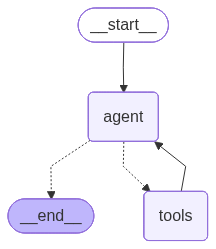

In [17]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [18]:
def print_langgraph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [19]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_sLGRQj5MfBsSpu9T15cajQIB)
 Call ID: call_sLGRQj5MfBsSpu9T15cajQIB
  Args:
    query: urinary signs urgent veterinary care cat emergency warning signs inability to urinate straining blood in urine frequent trips litter box pain vocalizing

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.761]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or no urine may

In [20]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t help with that question.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:

create_agent hid the whole loop: binding the tools to the model, injecting the system prompt, the decision to call tools or answer, executing the tool, and looping the result back to the model. The LangGraph version makes all of that explicit as nodes (agent, tools), a conditional edge (tools_condition), and a loop-back edge. 

Choose middleware when you want to observe or constrain an existing loop without changing its shape, like logging, a model-call limit, or a tool-call budget. Change the graph itself when you need different control flow, like adding a deterministic route before the model, a grader after retrieval, or custom state. Middleware adjusts behavior around the loop; editing the graph changes the loop.

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [21]:
# Activity #2: deterministic scope routing before the model-tools loop.

# A small keyword list stands in for a cheap, deterministic scope check.
CAT_HEALTH_KEYWORDS = (
    "cat", "kitten", "feline", "vet", "litter", "vaccine", "vaccination",
    "parasite", "flea", "tick", "worm", "dental", "teeth", "urinary",
    "kidney", "nutrition", "diet", "food", "hydration", "senior",
    "behavior", "stress", "symptom", "vomit", "paw", "fur", "coat",
)


# 2. Routing function: cat-health-looking questions go to the model, others bypass it.
def route_question(state: MessagesState) -> str:
    """Route on keywords before any model call happens."""
    last_message = state["messages"][-1]
    text = getattr(last_message, "content", None)
    if text is None:
        text = last_message.get("content", "")
    text = text.lower()
    if any(keyword in text for keyword in CAT_HEALTH_KEYWORDS):
        return "agent"
    return "out_of_scope"


# 1. out_of_scope node: answers with a fixed scope message, no model or tool call.
def out_of_scope(state: MessagesState):
    """Return a brief scope message without invoking the model."""
    message = (
        "This assistant is scoped to the cat health guideline corpus, "
        "so I can only help with cat health questions."
    )
    return {"messages": [{"role": "assistant", "content": message}]}


# 3. New graph: route immediately after START, otherwise the same agent-tools loop.
routed_builder = StateGraph(MessagesState)
routed_builder.add_node("agent", call_model)
routed_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))
routed_builder.add_node("out_of_scope", out_of_scope)

routed_builder.add_conditional_edges(
    START,
    route_question,
    {"agent": "agent", "out_of_scope": "out_of_scope"},
)
routed_builder.add_conditional_edges("agent", tools_condition)
routed_builder.add_edge("tools", "agent")
routed_builder.add_edge("out_of_scope", END)

routed_agent = routed_builder.compile()
print("Compiled the scope-routed LangGraph agent.")


# 4. Test a cat-health question, an unrelated question, and an ambiguous one.
routed_questions = [
    "What signs of dental disease should I watch for in my cat?",  # cat health
    "Who won the 2022 FIFA World Cup?",                            # clearly unrelated
    "How often should I schedule checkups?",                       # ambiguous, no cat keyword
]

for question in routed_questions:
    print("\n" + "=" * 100)
    print("QUESTION:", question)
    inputs = {"messages": [{"role": "user", "content": question}]}
    for chunk in routed_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if not update:
                print(update)
                continue
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue
            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:800]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

Compiled the scope-routed LangGraph agent.

QUESTION: What signs of dental disease should I watch for in my cat?

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_shF4kgqUshS4YRHNY8Luz8t3)
 Call ID: call_shF4kgqUshS4YRHNY8Luz8t3
  Args:
    query: cat dental disease signs to watch for symptoms oral health bad breath drooling eating difficulty pawing at mouth gingivitis tooth resorption guidance

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=6, start_index=3728, score=0.706]
## Dental And Oral Health

Dental disease is common in cats. Warning signs include bad breath, drooling, pawing at the mouth, dropping food, chewing on one side, decreased appetite, red gums, visible tartar, and facial swelling. Cats may continue eating despite oral pain, so normal appetite does not rule out dental disease.

Veterinary dental exams he

### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:

The cat dental question went through the model-tools loop and retrieved. The World Cup question and the checkups question both bypassed the loop and hit the out_of_scope node, since neither contained a keyword.

The ambiguous question ("How often should I schedule checkups?") was a false negative. It is plausibly about the cat, but it has no word from the keyword list, so the deterministic route sent it to out_of_scope and the user never got a real answer. This is exactly where keyword routing is brittle.

The route is cheap and fast for clearly unrelated questions, since they skip the model and tools entirely, which saves tokens and latency, and it makes scope rejection predictable instead of relying on the model's judgment. The cost is quality: a keyword list has no understanding, so it misroutes questions phrased without a listed word, and it would also wrongly admit off-topic questions that happen to contain a keyword. A model-based or classifier-based scope check would be more accurate but slower and not free.

## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

Compiled the corrective RAG graph.



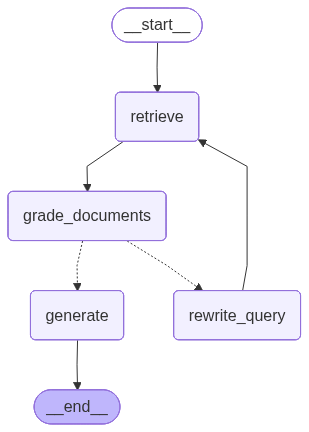


QUESTION: What urinary signs suggest my cat needs urgent veterinary care?
[retrieve] attempt 1 for query: 'What urinary signs suggest my cat needs urgent veterinary care?' -> 4 chunks
[grade] kept 2/4 chunks as relevant

Retrievals used: 1 | relevant chunks kept: 2

ANSWER:
Urinary signs that suggest your cat may need **urgent veterinary care** include:

- **Straining to urinate**
- **Repeated trips to the litter box**
- **Crying in the litter box**
- **Blood in the urine**
- **Urinating outside the box**
- **Producing very little urine**
- **Not producing urine / inability to urinate**

A cat that is **straining to urinate, repeatedly visiting the litter box, crying, or producing little or no urine** may have a **urinary emergency**. **Male cats are especially at risk for life-threatening urinary blockage.**

Please **contact a veterinarian for medical decisions or urgent symptoms**.

QUESTION: Which cat insurance company should I buy a policy from?
[retrieve] attempt 1 for query: 'W

In [22]:
# Advanced Build: corrective RAG loop (grade -> rewrite -> retry, with a cap).
from typing import TypedDict

MAX_RETRIEVALS = 2  # initial retrieval + at most one rewrite-and-retry


class CRAGState(TypedDict):
    question: str
    documents: list
    generation: str
    attempts: int


def crag_retrieve(state: CRAGState):
    """Retrieve chunks for the current question and count the attempt."""
    scored = vector_store.similarity_search_with_score(state["question"], k=retrieval_k)
    documents = [doc for doc, _score in scored]
    attempts = state.get("attempts", 0) + 1
    print(f"[retrieve] attempt {attempts} for query: {state['question']!r} -> {len(documents)} chunks")
    return {"documents": documents, "attempts": attempts}


GRADE_PROMPT = """You are grading whether a retrieved document is relevant to a cat health question.

Question: {question}

Document:
{document}

Reply with a single word: "yes" if the document contains information that helps answer the question, otherwise "no"."""


def crag_grade_documents(state: CRAGState):
    """Keep only chunks the model judges relevant to the question."""
    relevant = []
    for doc in state["documents"]:
        verdict = llm.invoke(
            GRADE_PROMPT.format(question=state["question"], document=doc.page_content[:1500])
        ).content.strip().lower()
        if verdict.startswith("yes"):
            relevant.append(doc)
    print(f"[grade] kept {len(relevant)}/{len(state['documents'])} chunks as relevant")
    return {"documents": relevant}


def decide_after_grading(state: CRAGState) -> str:
    """Route to generate if we have relevant context or hit the cap; otherwise rewrite."""
    if state["documents"]:
        return "generate"
    if state["attempts"] >= MAX_RETRIEVALS:
        return "generate"  # cap reached; generate will refuse gracefully
    return "rewrite_query"


REWRITE_PROMPT = """The search for cat health context returned no relevant results.
Rewrite the user's question into a single improved semantic search query for a cat health guideline corpus.
Original question: {question}
Return only the rewritten query."""


def crag_rewrite_query(state: CRAGState):
    """Produce a better search query and loop back to retrieve."""
    new_query = llm.invoke(REWRITE_PROMPT.format(question=state["question"])).content.strip()
    print(f"[rewrite] {state['question']!r} -> {new_query!r}")
    return {"question": new_query}


GENERATE_PROMPT = """You are a cat health guideline assistant. Answer the question using only the context below.
If the context is empty or does not contain the answer, say you do not have enough information in the cat health guidelines to answer.
Always remind the user to contact a veterinarian for medical decisions or urgent symptoms.

Question: {question}

Context:
{context}"""


def crag_generate(state: CRAGState):
    """Answer only from the kept context, refusing when there is none."""
    context = "\n\n".join(doc.page_content for doc in state["documents"])
    answer = llm.invoke(
        GENERATE_PROMPT.format(question=state["question"], context=context)
    ).content
    return {"generation": answer}


crag_builder = StateGraph(CRAGState)
crag_builder.add_node("retrieve", crag_retrieve)
crag_builder.add_node("grade_documents", crag_grade_documents)
crag_builder.add_node("rewrite_query", crag_rewrite_query)
crag_builder.add_node("generate", crag_generate)

crag_builder.add_edge(START, "retrieve")
crag_builder.add_edge("retrieve", "grade_documents")
crag_builder.add_conditional_edges(
    "grade_documents",
    decide_after_grading,
    {"generate": "generate", "rewrite_query": "rewrite_query"},
)
crag_builder.add_edge("rewrite_query", "retrieve")
crag_builder.add_edge("generate", END)

crag_agent = crag_builder.compile()
print("Compiled the corrective RAG graph.\n")

try:
    display(Image(crag_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(crag_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")


def run_crag(question: str):
    print("\n" + "=" * 100)
    print("QUESTION:", question)
    result = crag_agent.invoke({"question": question, "documents": [], "attempts": 0})
    print(f"\nRetrievals used: {result['attempts']} | relevant chunks kept: {len(result['documents'])}")
    print("\nANSWER:\n" + result["generation"])


# In-corpus question: grader passes on the first try, answers in one retrieval.
run_crag("What urinary signs suggest my cat needs urgent veterinary care?")

# Cat-related but out-of-corpus question: grader rejects, rewrite + retry, then cap -> grounded refusal.
run_crag("Which cat insurance company should I buy a policy from?")

### Advanced Build Write-up

What I changed

I extended the explicit LangGraph version into a corrective RAG loop. Instead of retrieving once and answering, the new graph has four nodes: retrieve, grade_documents, rewrite_query, and generate. After retrieval, an LLM grader scores each chunk as relevant or not. A conditional edge then decides what happens next: if any chunk is relevant, go to generate; if none are relevant and we are under the retrieval cap, rewrite the query and retrieve again; if the cap is hit, generate anyway with whatever context is left. The generate node answers only from the kept context and refuses when that context is empty. A cap of two retrievals (one rewrite) prevents an infinite loop.

Why I changed it

The base agent trusts whatever the retriever returns. If the search query is weak or the corpus does not cover the topic, the model can still answer from low-quality or empty context. The grader adds a quality gate, the rewrite gives the system a second attempt with a better query, and the cap plus the grounded generate node stop it from looping forever or answering ungrounded.

How retrieval and answer quality changed

For an in-corpus question like urinary warning signs, the grader passes the chunks on the first try, so it answers in one retrieval, same as before but now with a relevance check in front. For a cat-related but out-of-corpus question like cat insurance, the grader rejects every chunk, the query is rewritten and retried, and when the second attempt still finds nothing relevant the cap forces a generate that says the guidelines do not have that information instead of inventing an answer. The visible effect is fewer ungrounded answers and an explicit, inspectable retrieval-quality decision instead of a blind retrieve-then-answer.

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.